In [ ]:
# --- Repository root ---------------------------------------------------------
# Every path in this notebook is relative to the repository root, not to notebooks/.
# Resolve the root and work from there, so the notebook behaves the same whether it
# was opened from notebooks/ or from the repository root.
import os
from pathlib import Path

for _d in (Path.cwd(), *Path.cwd().parents):
    if (_d / "processing_scripts").is_dir() and (_d / "README.md").is_file():
        os.chdir(_d)
        break
else:
    raise RuntimeError("repository root not found — open this notebook inside a clone "
                       "of the H3K27me2 repository")
print("working directory:", Path.cwd())

In [1]:
import os
import numpy as np
import pandas as pd
#import scanpy as sc
#import pyranges as pr
import warnings
pd.options.mode.chained_assignment = None  # default='warn'
import fnmatch

In [2]:
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize
from matplotlib.cm import ScalarMappable
from matplotlib.lines import Line2D
import matplotlib.patches as patches
from matplotlib.ticker import MultipleLocator

import seaborn as sns

from scipy.stats import gaussian_kde
from scipy import stats
# from tabulate import tabulate
# from sklearn.decomposition import PCA
import os
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import linkage, leaves_list
# from sklearn.cluster import KMeans


In [4]:
%matplotlib inline
# figure size & color
matplotlib.rcParams['figure.dpi'] = 100 # 150 dpi resolution
matplotlib.rcParams['image.cmap'] = 'Spectral_r' # preferred color map
matplotlib.rcParams['figure.figsize'] = [8, 8] # Square
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42


# no bounding boxes or axis:
matplotlib.rcParams['axes.spines.bottom'] = "on"
matplotlib.rcParams['axes.spines.top'] = "on"
matplotlib.rcParams['axes.spines.left'] = "on"
matplotlib.rcParams['axes.spines.right'] = "on"
warnings.filterwarnings(action="ignore", module="matplotlib", message="findfont")

In [5]:
font = {#'family' : 'Helvetica',
        'weight' : 'normal',
        'size'   : 15}

matplotlib.rc('font', **font)
matplotlib.rcParams['axes.linewidth'] = 2 #set the value globally

In [6]:
fig_dir = 'figures/'


# Peakprint 50 Slope fingerprints

In [464]:
bins = pd.read_csv("data/2024/SH_all_data/peakPRINT_50/MERGED_downsampled_bins.tsv", 
                   header = 0, 
                      index_col=False, 
                   sep='\t')
bins['dataset'] = bins['source_file'].str.split('_', expand=True)[0] + '_' + bins['source_file'].str.split('_', expand=True)[1]
bins['epitope'] = bins['source_file'].str.split('_', expand=True)[0]
bins['celltype'] = bins['source_file'].str.split('_', expand=True)[1]
bins.head()

,chr,start,end,coverage,rank,cumsum,source_file,dataset,epitope,celltype
0,chr1,0,50,0.000000,1.557600e-08,0.000000,K27ac_H_no_chrM_100pct.1-1000.bedGraph_downsam...,K27ac_H,K27ac,H
1,chr1,122671950,122672000,13.606536,9.999000e-01,0.997052,K27ac_H_no_chrM_100pct.1-1000.bedGraph_downsam...,K27ac_H,K27ac,H
2,chr14_GL000225v1_random,6800,6850,10.142265,9.998000e-01,0.995918,K27ac_H_no_chrM_100pct.1-1000.bedGraph_downsam...,K27ac_H,K27ac,H
3,chr11,71787000,71787050,8.946956,9.997000e-01,0.994981,K27ac_H_no_chrM_100pct.1-1000.bedGraph_downsam...,K27ac_H,K27ac,H
4,chr17_KI270729v1_random,1000,1050,8.285240,9.996000e-01,0.994131,K27ac_H_no_chrM_100pct.1-1000.bedGraph_downsam...,K27ac_H,K27ac,H


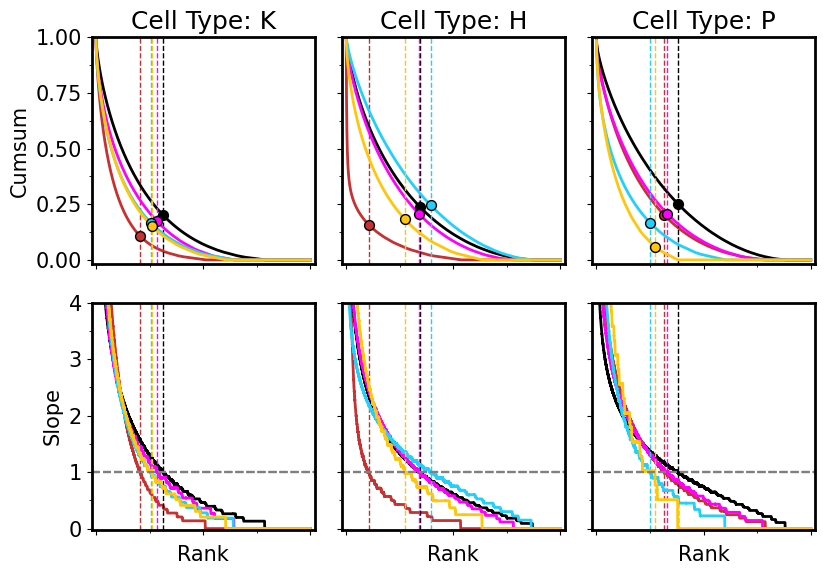

In [466]:
# Create a figure with 3 rows (one per plot type)
fig, axs = plt.subplots(2, 3, figsize=(8.5, 6), sharex='col', sharey='row')
# Define colors and hue order
cell_types = ['K','H','P']
hue_order = ['K27me3', 'K27me2', "K27me1", "K27ac", "P2"]
palette = ['#C73131', '#000000', '#FF00FF', '#22D0FB', '#FFC60B']

# Loop through each cell type and create subplots in corresponding columns
for col, cell_type in enumerate(cell_types):
    df_filtered = bins[bins['celltype'] == cell_type]

    for epitope, color in zip(hue_order, palette):
        df_epitope = df_filtered[df_filtered['epitope'] == epitope].sort_values(by='rank')
        # Compute first derivative (slope)
        df_epitope['first_derivative'] = np.gradient(df_epitope['cumsum'], df_epitope['rank'])
        df_epitope['rank'] = 1 - df_epitope['rank']
        
        # Find the index where slope is closest to 1
        idx_closest = (df_epitope['first_derivative'] - 1).abs().idxmin()
        x_slope_1 = df_epitope.loc[idx_closest, 'rank']
        y_slope_1 = df_epitope.loc[idx_closest, 'cumsum']

        # Plot original cumulative sum (Row 1)
        sns.lineplot(data=df_epitope, x='rank', y='cumsum', color=color, linewidth=2, ax=axs[0, col])
        axs[0, col].scatter(x_slope_1, y_slope_1, color=color, edgecolor='black', zorder=3, s=50)
        axs[0, col].axvline(x=x_slope_1, color=color, linestyle='--', linewidth=1)  # <--- ADD THIS

        axs[0, col].set_ylim(-0.02,1)
        axs[0, col].set_xlim(-0.02,1.02)
        axs[0, col].yaxis.set_minor_locator(MultipleLocator(0.125))
        
        # Plot first derivative (Row 2)
        sns.lineplot(data=df_epitope, x='rank', y='first_derivative', color=color, linewidth=2, ax=axs[1, col])
        axs[1, col].axvline(x=x_slope_1, color=color, linestyle='--', linewidth=1)  # <--- ADD THIS
        
        axs[1, col].set_ylim(-0.02,4)
        axs[1, col].set_xlim(-0.02,1.02)
        axs[1, col].yaxis.set_minor_locator(MultipleLocator(0.5))
        axs[1, col].axhline(y=1, ls='--', c='grey')

    # Set titles and labels
    axs[0, col].set_title(f'Cell Type: {cell_type}')
    axs[1, col].set_xlabel("Rank")

# Set row labels
axs[0, 0].set_ylabel("Cumsum")
axs[1, 0].set_ylabel("Slope")

# Apply detailed grid to all subplots
for row in axs:
    for ax in row:
        # ax.minorticks_on()
        # ax.set_xticks([0, 0.25, 0.5, 0.75, 1.0])
        # Grid settings
        # ax.xaxis.set_major_locator(MultipleLocator(0.2))  # major ticks every 100 (optional)
        ax.xaxis.set_minor_locator(MultipleLocator(.25))   # minor ticks every 10
        # ax.grid(True, which='both', axis='y')
        ax.set_xticklabels('')


# Adjust layout for better spacing
plt.tight_layout()
# Save the figure
plt.savefig(
    fig_dir + '250411_K27_HKP_fingerprint_peakPRINT_50_slope.pdf',
    transparent=True,
    bbox_inches='tight',
    #facecolor = 'black'
)
# Show the plot
plt.show()


# min300 coverage

In [479]:
min300_df = pd.read_csv("data/2024/SH_all_data/downsample_peakPRINT_slope1_min300/min350/downsample_peakPRINT_slope1_min350_meta_v1.tsv", 
                   header = 0, 
                      index_col=False, 
                   sep='\t')
min300_df

In [480]:
min300_df = min300_df[min300_df['PercentSampled'] == 100]
min300_df

In [481]:
min300_df['FileName'] = min300_df['BedFileName'].str.split('/', expand = True)[12]
min300_df['Epitope'] = min300_df['FileName'].str.split('_', expand = True)[0]
min300_df['Cell Type'] = min300_df['FileName'].str.split('_', expand = True)[1]
min300_df['Genome Fraction'] = min300_df['GenomeCovered']/100
min300_df

/loc/scratch/18092657/ipykernel_15682/306177164.py:53: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[i].legend().set_visible(False)
/loc/scratch/18092657/ipykernel_15682/306177164.py:53: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[i].legend().set_visible(False)


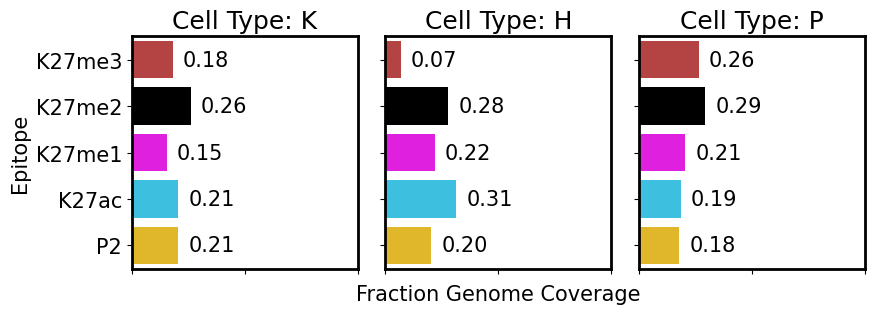

In [85]:
# Define colors and hue order
# cell_types = bins['celltype'].unique()
cell_types = ['K','H','P']
hue_order = ['K27me3', 'K27me2', "K27me1", "K27ac", "P2"]
palette = ['#C73131', '#000000', '#FF00FF', '#22D0FB', '#FFC60B']

# Convert to DataFrame
df_slope = pd.DataFrame(min300_df, columns=['Epitope', 'Cell Type', 'Genome Fraction'])

# Create the Seaborn bar plot for each cell type
fig, axs = plt.subplots(1, 3, figsize=(9, 3.4), sharex=True, sharey=True)

for i, cell_type in enumerate(cell_types):
    df_subset = df_slope[df_slope['Cell Type'] == cell_type]

    # Ensure the bars are sorted by genome fraction
    # df_subset = df_subset.sort_values(by='Genome Fraction', ascending=True)

    # Plot using Seaborn
    sns.barplot(
        data=df_subset,
        x='Genome Fraction',
        y='Epitope',
        hue='Epitope',  # Use hue to match colors
        hue_order = hue_order,
        order=hue_order,
        palette={epitope: color for epitope, color in zip(hue_order, palette)},
        dodge=False,
        ax=axs[i]
    )

# Reverse x-axis so bars start from the right
    axs[i].invert_xaxis()
    axs[i].set_xlim(0, 1)  # X-axis represents genome fraction (0 to 1)
    axs[i].set_title(f"Cell Type: {cell_type}")
    axs[i].set_xticklabels('')

    # Annotate each bar at the end
    for index, row in df_subset.iterrows():
        axs[i].text(
            row['Genome Fraction'] + 0.25,  # Adjusted for positioning (shift left)
            row['Epitope'],
            f"{row['Genome Fraction']:.2f}",
            color='black',
            va='center',
            ha='right'
        )
        
    if i == 1:
        axs[i].set_xlabel('Fraction Genome Coverage')
    else:
        axs[i].set_xlabel('')
        axs[i].legend().set_visible(False)

# Adjust layout for better spacing
plt.tight_layout()
# Save the figure
plt.savefig(
    fig_dir + '250411_K27_HKP_fingerprint_peakPRINT_50_slope_genomeCov_min300.pdf',
    transparent=True,
    bbox_inches='tight',
    #facecolor = 'black'
)
# Show the plot
plt.show()


# Downsampling

In [378]:
dataset = pd.read_csv("data/2024/SH_all_data/downsample_peakPRINT_slope1_min300/min350/downsample_peakPRINT_slope1_min350_meta_v1.tsv", 
                   header = 0, 
                   sep='\t',
                 )
dataset1 = pd.read_csv("data/2024/SH_all_data/downsample_peakPRINT_slope1_min300/min350/downsample_peakPRINT_slope1_min350_meta_v2.tsv", 
                   header = 0,
                   sep='\t')
# dataset2 = pd.read_csv("data/2024/SH_all_data/downsample_peakPRINT_slope1_min300/downsample_peakPRINT_slope1_min300_meta_v3.tsv", 
#                    header = 0, 
#                    sep='\t')
dataset = pd.concat([dataset,dataset1])
dataset
dataset.reset_index(inplace = True)

In [379]:
dataset['Filename'] = dataset['BedFileName'].str.split('/', expand=True)[12].str.split('.', expand=True)[0]
dataset['epitope'] = dataset['Filename'].str.split('_', expand=True)[0]
dataset['celltype'] = dataset['Filename'].str.split('_', expand=True)[1]

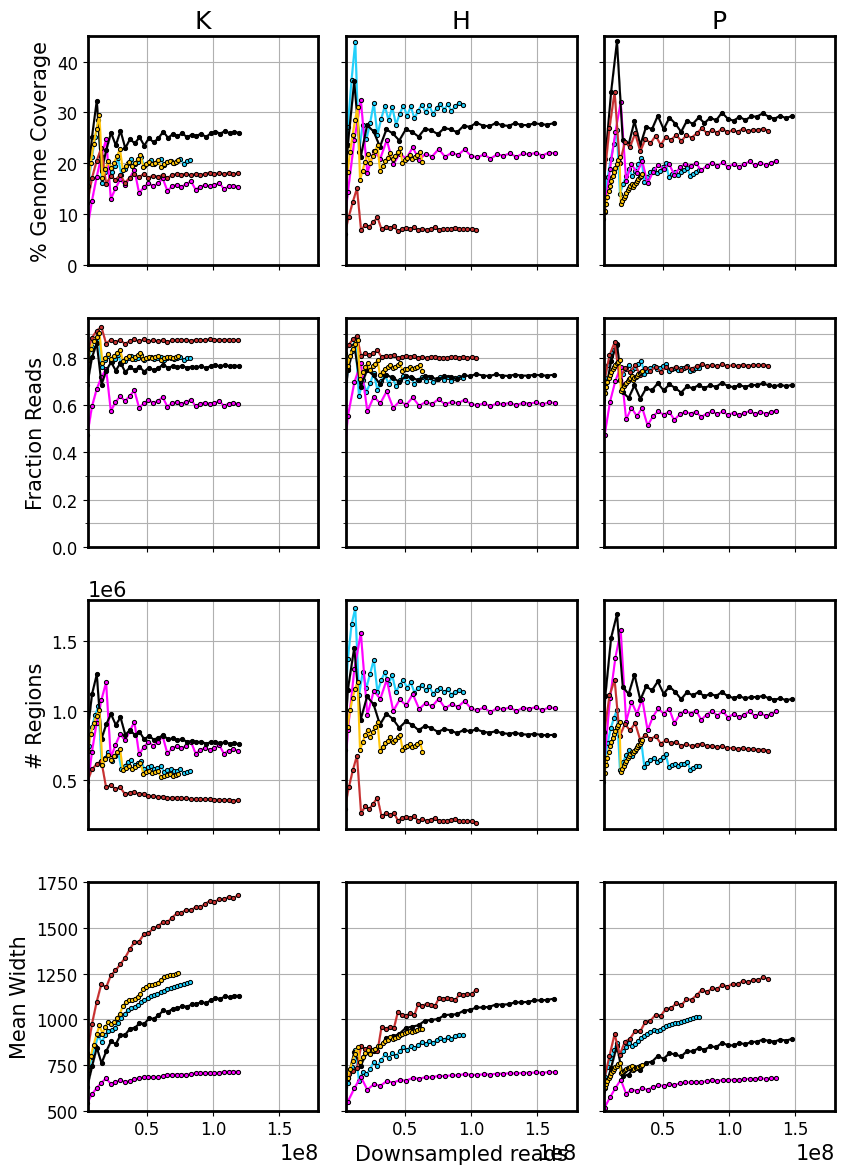

In [383]:
# Assuming 'dataset' is your DataFrame and 'fig_dir' is defined for saving the figure
selected_epitopes = ['K27ac', 'K27me1', 'K27me2', 'K27me3', 'P2']
selected_celltypes = ['K', 'H', 'P']
metrics = ['GenomeCovered', 'FractionOfReadsInPeaks', 'nPeaks', 'avg_Peakwidth']

# Filter dataset for selected celltypes and epitopes
plot_data = dataset[(dataset['celltype'].isin(selected_celltypes)) & (dataset['epitope'].isin(selected_epitopes))]

# Create a figure and a set of subplots
fig, axs = plt.subplots(len(metrics), len(selected_celltypes), figsize=(8.7, 12), sharex=True, sharey='row')
dot_markers = {epitope: '.' for epitope in selected_epitopes}
for i, metric in enumerate(metrics):
    for j, celltype in enumerate(selected_celltypes):
        ax = axs[i, j]
        data = plot_data[plot_data['celltype'] == celltype]
        sns.lineplot(data=data,
                        x='NumberOfReads',
                        y=metric,
                        hue='epitope',
                        style = 'epitope',
                        palette=['#22D0FB', '#FF00FF', '#000000', '#C73131', '#FFC60B'],
                        legend = False,
                        errorbar = 'ci',
                        markers=dot_markers,
                        markeredgecolor='black',    
                         markersize=6,
                         linewidth = 1.5,
                        dashes=False,
                         ax=ax
                    )
        ax.set_title(f'{celltype}' if i == 0 else '')
        # ax.set_xscale('log')
        ax.set_xlim(xmin = 5*10**6, xmax = 1.8*10**8)
        ax.grid(True)
        ax.tick_params(axis='x', labelsize=12)
        ax.tick_params(axis='y', labelsize=12)
        
        # Only show the legend for the first plot
        if i == 0:
            ax.set_ylim(ymin = 0,ymax = 45)
            ax.set_ylabel('% Genome Coverage' if j == 0 else '')
        if i == 1:
            ax.set_ylim(ymin = 0)
            ax.yaxis.set_minor_locator(MultipleLocator(.1))
            ax.grid(True, which='both', axis='y')
            ax.set_ylabel('Fraction Reads' if j == 0 else '')

        if i == 2:
            ax.set_ylim(ymin = .15*10**6, ymax = 6.05**8)
            ax.set_ylabel('# Regions' if j == 0 else '')
            
        if i == 3:
            ax.set_ylim(ymin = 500, ymax = 1750)
            ax.set_xlabel('Downsampled reads' if j == 1 else '')
            ax.set_ylabel('Mean Width' if j == 0 else '')


# Adjust the layout
plt.tight_layout()

# Save the figure
plt.savefig(
    fig_dir + '250414_downsampled_coverage_min350.pdf',
    transparent=True,
    bbox_inches='tight',
    #facecolor = 'black'
)

plt.show()


# Rank peaks

In [7]:
def read_bed(file_path):
    """Read a BED file and return a DataFrame."""
    columns = ['chr', 'start', 'end', 'sum', 'mean']
    df = pd.read_csv(file_path, sep='\t', header=None, names=columns, usecols=[0, 1, 2,3,4])
    return df

def compute_interval_metrics(df):
    """Compute interval size and distance to the next interval."""
    df['interval_size'] = df['end'] - df['start']
    df['distance_to_next'] = df['start'].shift(-1) - df['end']
    df.loc[df.index[-1], 'distance_to_next'] = np.nan  # Set NaN for the last interval
    return df

def downsample_bed(df, n=10000):
    """Downsample the BED file to n entries."""
    if len(df) > n:
        df = df.sample(n=n, random_state=42).sort_index()
    return df

def process_bed_files(directory, pattern):
    """Process all BED files matching a pattern in the specified directory and return merged DataFrames."""
    interval_sizes = []
    distances_to_next = []

    for filename in os.listdir(directory):
        if fnmatch.fnmatch(filename, pattern):
            file_path = os.path.join(directory, filename)
            df = read_bed(file_path)
            df = compute_interval_metrics(df)
            # df = df[df['interval_size'] > 300]
            # df = downsample_bed(df)
            
            df['file_name'] = filename
            df['dataset'] = df['file_name'].str.split('_', expand=True)[0] + '_' + df['file_name'].str.split('_', expand=True)[1]
            df['epitope'] = df['file_name'].str.split('_', expand=True)[0]
            df['celltype'] = df['file_name'].str.split('_', expand=True)[1]
            
            interval_sizes.append(df[['chr', 'start', 'end', 'sum', 'mean','interval_size','distance_to_next', 'file_name','dataset','epitope', 'celltype']])

    interval_size_df = pd.concat(interval_sizes, ignore_index=True)

    return interval_size_df

In [8]:
# Specify the directory containing the BED files and the pattern to match
input_directory = 'data/2024/SH_all_data/downsample_peakPRINT_slope1_min300/min350/'
# pattern = '*_reproducibility_95plus.bed'  # Example pattern to match files with '_filtered.bed'
pattern = 'K27me3_K_peak_coverage.bed'
# Process the BED files and get merged DataFrames
interval_size_df = process_bed_files(input_directory, pattern)

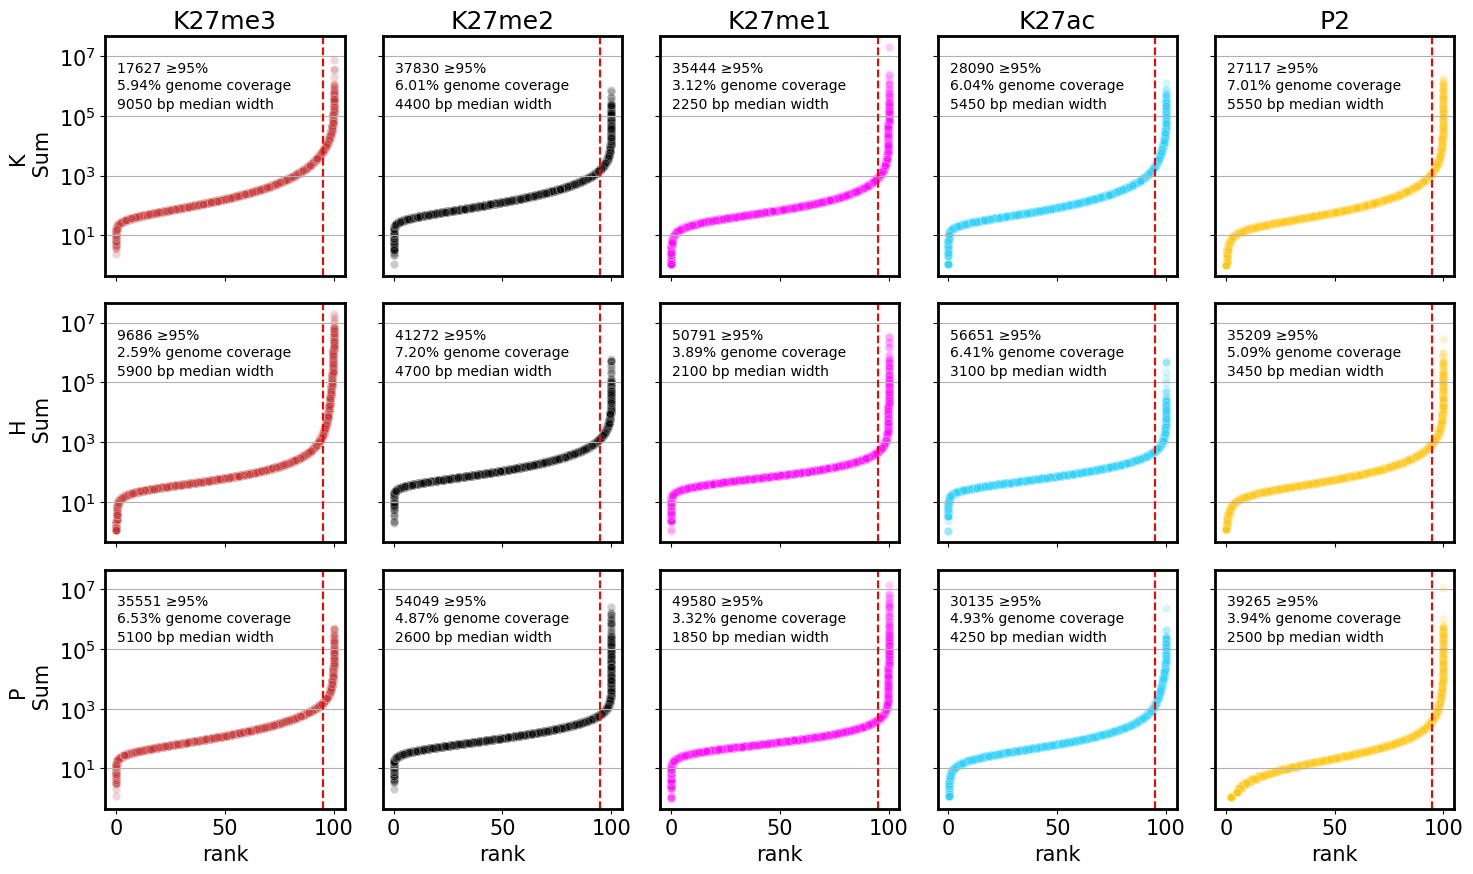

In [12]:
import os

# Define the desired order of epitopes
epitope_order = ["K27me3", "K27me2", "K27me1", "K27ac", "P2"]
celltype_order = ["K", "H", "P"]

# Define custom colors for each epitope
epitope_colors = {
    "K27me3": "#C73131",  # Red
    "K27me2": "#000000",  # Black
    "K27me1": "#FF00FF",  # Magenta
    "K27ac": "#22D0FB",   # Blue
    "P2": "#FFC60B"       # Yellow
}

# Filter the dataset to include only specified epitopes in order
df = interval_size_df
df_filtered = df[df["epitope"].isin(epitope_order) & df["celltype"].isin(celltype_order)]
df_filtered["epitope"] = pd.Categorical(df_filtered["epitope"], categories=epitope_order, ordered=True)
df_filtered["celltype"] = pd.Categorical(df_filtered["celltype"], categories=celltype_order, ordered=True)


#remove non_standard chr
mask = df_filtered['chr'].str.match(r"^chr(?:[1-9]|1[0-9]|2[0-2]|X|Y)$")
df_filtered = df_filtered[mask].copy()

# Create subplots: 2D grid (cell type rows, epitope columns)
fig, axes = plt.subplots(len(celltype_order), len(epitope_order), figsize=(15, 9), sharex=True, sharey=True)

# Plot each epitope in a separate subplot
for i, celltype in enumerate(celltype_order):
    for j, epitope in enumerate(epitope_order):
        subset = df_filtered[(df_filtered["epitope"] == epitope) & (df_filtered["celltype"] == celltype)]
        subset['rank'] = subset['sum'].rank()/len(subset)*100

        ax = axes[i, j]

        # Scatter plot
        sns.scatterplot(data=subset, x="rank", y="sum", alpha=0.2, ax=ax, color=epitope_colors[epitope], rasterized=True,)
        ax.set_yscale('log')
        ax.axvline(x=95, c='red', ls='--')
        ax.grid(True, which='major', axis='y')

        # Annotate with the fraction of peaks at reproducibility >= 95
        up95 = subset[subset["rank"] >= 95]
        fraction_95 = len(up95)
        ax.annotate(f"{fraction_95} ≥95%", xy=(0.05, 0.85), xycoords="axes fraction", fontsize=10, color="black")
        cov = up95['interval_size'].sum() / 3298912062
        ax.annotate(f"{cov:.2%} genome coverage", xy=(0.05, 0.78), xycoords="axes fraction", fontsize=10, color="black")
        width = up95['interval_size'].median()
        ax.annotate(f"{width:.0f} bp median width", xy=(0.05, 0.7), xycoords="axes fraction", fontsize=10, color="black")

        os.makedirs("data/2024/SH_all_data/downsample_peakPRINT_slope1_min300/min350/top95",
                    exist_ok=True)
        up95.sort_values(by = 'interval_size',ascending = False ).to_csv(f"data/2024/SH_all_data/downsample_peakPRINT_slope1_min300/min350/top95/{epitope}_{celltype}_top95regions.bed", 
                        sep='\t', index=False, header = False, columns = ['chr','start','end','rank']
                       )

        # Set labels and titles
        if i == 0:
            ax.set_title(epitope)
        if j == 0:
            ax.set_ylabel(f"{celltype} \n Sum")

plt.tight_layout()
# Save the figure
plt.savefig(
    fig_dir + '250412_ranked_regions_min350.pdf',
    transparent=True,
    bbox_inches='tight'
)

# Show the plot
plt.show()